# Online Retail Customer Analysis
## Customer segments and repeat-purchase prediction

This project uses two years of sales data from a UK online store.

### Main question

Can past shopping behavior help us understand customer groups and predict who will buy again in the next 90 days?

### What this notebook covers

- Data checks and cleaning
- Sales and customer trends
- Cohort retention
- RFM customer segments
- Repeat-purchase prediction
- Model comparison and business ideas

> **Revenue note:** In this notebook, revenue means positive purchases from customers with an ID. Returns, cancelled orders, invalid prices, and purchases without a customer ID are not included in this number.

## 1. Setup

The random seed keeps the results consistent. If the Excel file is not available, the code downloads it from UCI. You can also use a local file by setting `ONLINE_RETAIL_DATA`.

In [1]:
from pathlib import Path
import os
import tempfile
import urllib.request
import zipfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-cache"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(min(4, os.cpu_count() or 1)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = ["#173F5F", "#20639B", "#3CAEA3", "#F6D55C", "#ED553B"]
pd.set_option("display.max_columns", 30)

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
local_override = os.getenv("ONLINE_RETAIL_DATA")
data_path = Path(local_override) if local_override else DATA_DIR / "online_retail_II.xlsx"

if not data_path.exists():
    zip_path = DATA_DIR / "online_retail_ii.zip"
    print("Downloading the UCI Online Retail II dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path) as archive:
        workbook_member = next(
            name for name in archive.namelist()
            if name.lower().endswith("online_retail_ii.xlsx")
        )
        with archive.open(workbook_member) as source, open(data_path, "wb") as target:
            target.write(source.read())

print(f"Using workbook: {data_path.name}")

Using workbook: online_retail_II.xlsx


In [3]:
sheets = pd.read_excel(
    data_path,
    sheet_name=["Year 2009-2010", "Year 2010-2011"],
    engine="openpyxl",
)
raw = pd.concat(sheets.values(), ignore_index=True)
raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Check the data

Each row is one product on an invoice, not a full order. Negative quantities and invoice numbers that start with `C` usually show returns or cancelled orders.

In [4]:
invoice_text = raw["Invoice"].astype(str)
quality_audit = pd.DataFrame(
    {
        "Measure": [
            "Rows", "Columns", "Date range", "Countries",
            "Unique invoices", "Unique products", "Unique customers",
            "Exact duplicate rows", "Missing customer IDs",
            "Cancellation / return rows", "Non-positive price rows",
        ],
        "Value": [
            f"{len(raw):,}", raw.shape[1],
            f"{raw['InvoiceDate'].min():%Y-%m-%d} to {raw['InvoiceDate'].max():%Y-%m-%d}",
            raw["Country"].nunique(), f"{raw['Invoice'].nunique():,}",
            f"{raw['StockCode'].nunique():,}", f"{raw['Customer ID'].nunique():,}",
            f"{raw.duplicated().sum():,}", f"{raw['Customer ID'].isna().sum():,}",
            f"{((raw['Quantity'] < 0) | invoice_text.str.startswith('C')).sum():,}",
            f"{(raw['Price'] <= 0).sum():,}",
        ],
    }
)
quality_audit

,Measure,Value
0,Rows,"1,067,371"
1,Columns,8
2,Date range,2009-12-01 to 2011-12-09
3,Countries,43
4,Unique invoices,"53,628"
5,Unique products,"5,305"
6,Unique customers,"5,942"
7,Exact duplicate rows,"34,335"
8,Missing customer IDs,"243,007"
9,Cancellation / return rows,"22,951"


### Cleaning steps

1. Remove exact duplicate rows.
2. Keep customers with a customer ID.
3. Keep purchases with a positive quantity and price.
4. Keep returns and cancellations in a separate table.

These steps are useful for customer analysis. However, the final revenue number is gross purchase revenue, not the company's full accounting revenue.

In [5]:
deduplicated = raw.drop_duplicates().copy()
identified = deduplicated.dropna(subset=["Customer ID"]).copy()
identified["Customer ID"] = identified["Customer ID"].astype("int64")

cancelled_mask = identified["Invoice"].astype(str).str.startswith("C")
returns = identified[cancelled_mask | (identified["Quantity"] < 0)].copy()
purchases = identified[
    (~cancelled_mask) & (identified["Quantity"] > 0) & (identified["Price"] > 0)
].copy()
purchases["Revenue"] = purchases["Quantity"] * purchases["Price"]

cleaning_steps = pd.Series(
    {
        "Raw rows": len(raw),
        "After exact deduplication": len(deduplicated),
        "With customer ID": len(identified),
        "Valid positive purchases": len(purchases),
    },
    name="Rows",
)
cleaning_steps.to_frame().assign(Rows=lambda x: x["Rows"].map("{:,}".format))

,Rows
Raw rows,"1,067,371"
After exact deduplication,"1,033,036"
With customer ID,"797,885"
Valid positive purchases,"779,425"


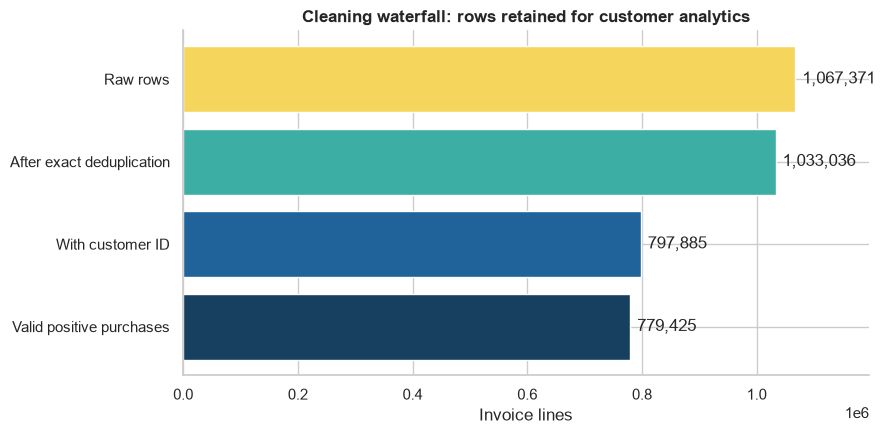

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(cleaning_steps.index[::-1], cleaning_steps.values[::-1], color=COLORS[:4])
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in cleaning_steps.values[::-1]], padding=5)
ax.set_title("Cleaning waterfall: rows retained for customer analytics", weight="bold")
ax.set_xlabel("Invoice lines")
ax.set_xlim(0, cleaning_steps.max() * 1.12)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cleaning_waterfall.png", dpi=160, bbox_inches="tight")
plt.show()

In [7]:
missing_customer_share = raw["Customer ID"].isna().mean()
retained_share = len(purchases) / len(raw)
display(Markdown(
    f"**What I found.** {missing_customer_share:.1%} of raw rows lack a customer ID, "
    f"so I cannot use those rows for customer-level analysis. After cleaning, {retained_share:.1%} "
    "of the original rows remain as valid purchases with a customer ID."
))

**What I found.** 22.8% of raw rows lack a customer ID, so I cannot use those rows for customer-level analysis. After cleaning, 73.0% of the original rows remain as valid purchases with a customer ID.

## 3. Explore the data

First, I look at the main business numbers. Then I check sales over time, countries, products, and customer retention.

In [8]:
order_value = purchases.groupby("Invoice")["Revenue"].sum()
orders_per_customer = purchases.groupby("Customer ID")["Invoice"].nunique()
uk_share = (
    purchases.loc[purchases["Country"] == "United Kingdom", "Revenue"].sum()
    / purchases["Revenue"].sum()
)

kpis = pd.DataFrame(
    {
        "KPI": [
            "Gross identified-customer revenue", "Orders", "Customers",
            "Median order value", "Median orders per customer",
            "Repeat-customer share", "United Kingdom revenue share",
        ],
        "Value": [
            f"£{purchases['Revenue'].sum():,.0f}", f"{purchases['Invoice'].nunique():,}",
            f"{purchases['Customer ID'].nunique():,}", f"£{order_value.median():,.0f}",
            f"{orders_per_customer.median():.0f}", f"{(orders_per_customer > 1).mean():.1%}",
            f"{uk_share:.1%}",
        ],
    }
)
kpis

,KPI,Value
0,Gross identified-customer revenue,"£17,374,804"
1,Orders,"36,969"
2,Customers,"5,878"
3,Median order value,£303
4,Median orders per customer,3
5,Repeat-customer share,72.4%
6,United Kingdom revenue share,82.8%


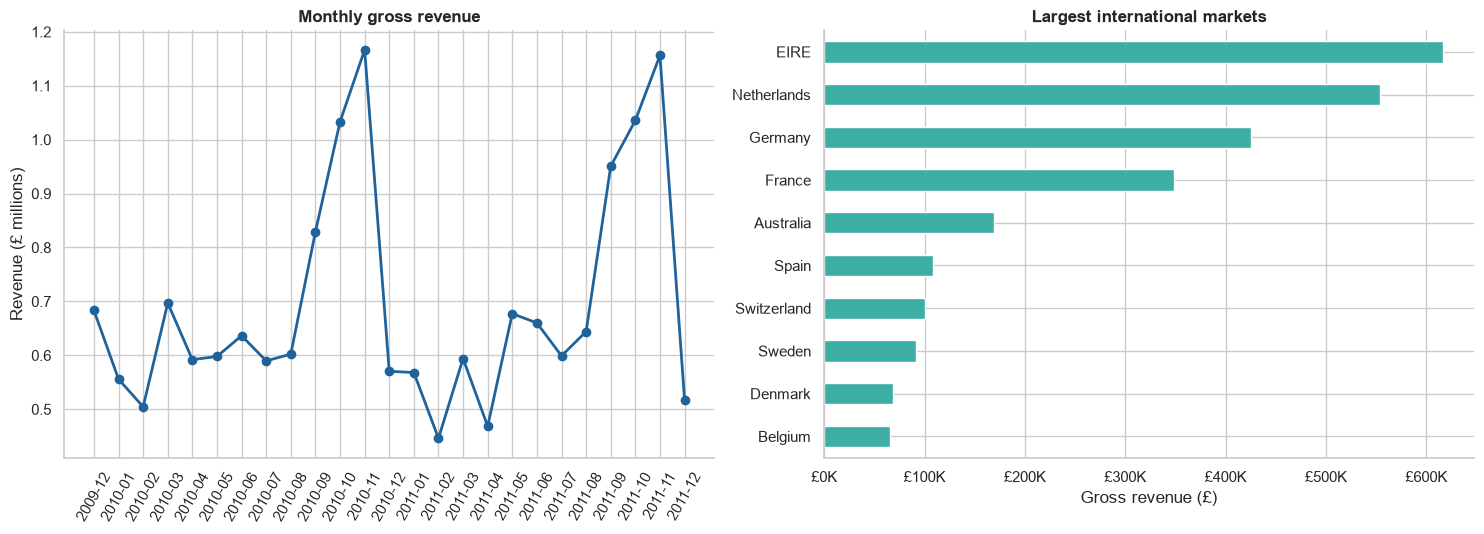

In [9]:
purchases["OrderMonth"] = purchases["InvoiceDate"].dt.to_period("M")
monthly_revenue = purchases.groupby("OrderMonth")["Revenue"].sum()

country_revenue = purchases.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
international_revenue = country_revenue.drop("United Kingdom", errors="ignore").head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(monthly_revenue.index.astype(str), monthly_revenue.values / 1e6,
             marker="o", color=COLORS[1], linewidth=2)
axes[0].set_title("Monthly gross revenue", weight="bold")
axes[0].set_ylabel("Revenue (£ millions)")
axes[0].tick_params(axis="x", rotation=60)

international_revenue.sort_values().plot(kind="barh", ax=axes[1], color=COLORS[2])
axes[1].set_title("Largest international markets", weight="bold")
axes[1].set_xlabel("Gross revenue (£)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"£{x/1000:.0f}K")

sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "revenue_trends_and_markets.png", dpi=160, bbox_inches="tight")
plt.show()

In [10]:
peak_month = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()
largest_international = international_revenue.index[0]
display(Markdown(
    f"**What I found.** The United Kingdom contributes {uk_share:.1%} of gross identified-customer "
    f"revenue. The peak month is **{peak_month}** at **£{peak_value:,.0f}**, while "
    f"**{largest_international}** is the largest market outside the UK. The late-year peaks suggest "
    "seasonality that should be considered when planning campaigns or evaluating a model."
))

**What I found.** The United Kingdom contributes 82.8% of gross identified-customer revenue. The peak month is **2010-11** at **£1,166,460**, while **EIRE** is the largest market outside the UK. The late-year peaks suggest seasonality that should be considered when planning campaigns or evaluating a model.

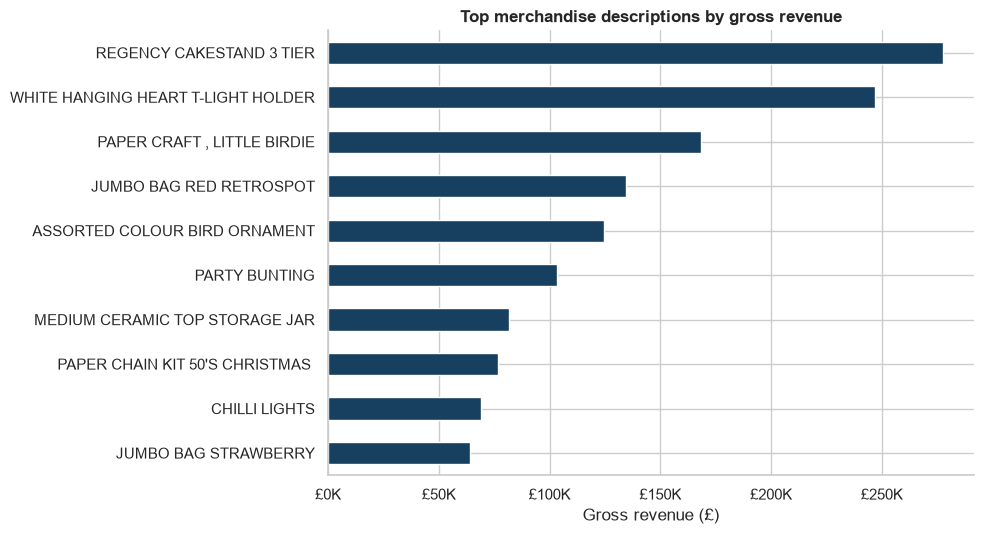

In [11]:
admin_descriptions = {
    "POSTAGE", "MANUAL", "CARRIAGE", "DOTCOM POSTAGE", "BANK CHARGES",
    "AMAZON FEE", "ADJUST BAD DEBT", "DISCOUNT",
}
merchandise = purchases[
    ~purchases["Description"].str.upper().isin(admin_descriptions)
].copy()
top_products = (
    merchandise.groupby("Description")["Revenue"].sum()
    .sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
top_products.sort_values().plot(kind="barh", ax=ax, color=COLORS[0])
ax.set_title("Top merchandise descriptions by gross revenue", weight="bold")
ax.set_xlabel("Gross revenue (£)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, pos: f"£{x/1000:.0f}K")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_products.png", dpi=160, bbox_inches="tight")
plt.show()

### Do customers come back?

Customers are grouped by the month of their first purchase. The heatmap shows the share of each group that bought again in later months. I only show groups with at least 100 customers and the first 12 months.

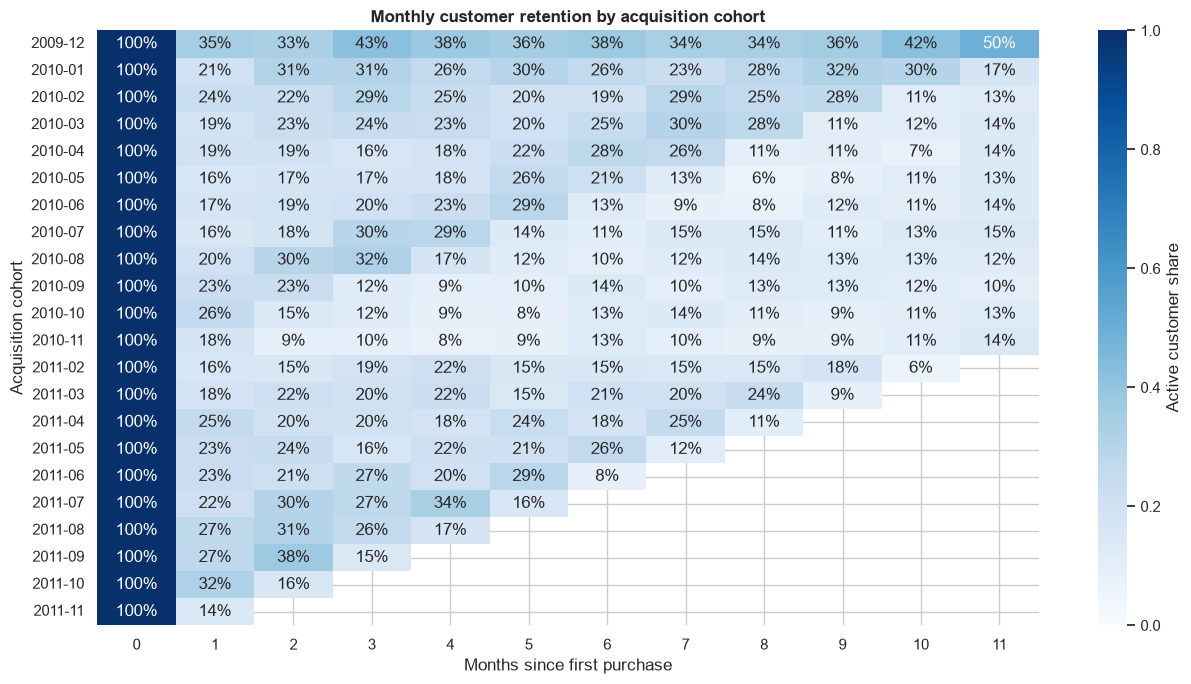

In [12]:
customer_months = purchases[["Customer ID", "OrderMonth"]].drop_duplicates()
first_month = customer_months.groupby("Customer ID")["OrderMonth"].min().rename("CohortMonth")
customer_months = customer_months.join(first_month, on="Customer ID")
customer_months["CohortIndex"] = (
    (customer_months["OrderMonth"].dt.year - customer_months["CohortMonth"].dt.year) * 12
    + customer_months["OrderMonth"].dt.month
    - customer_months["CohortMonth"].dt.month
)

cohort_counts = customer_months.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().unstack()
cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention_view = retention.loc[cohort_sizes >= 100, list(range(0, 12))]
retention_view.index = retention_view.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(retention_view, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Active customer share"}, ax=ax)
ax.set_title("Monthly customer retention by acquisition cohort", weight="bold")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Acquisition cohort")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cohort_retention.png", dpi=160, bbox_inches="tight")
plt.show()

In [13]:
mature_cohorts = retention_view.dropna(subset=[3])
month_3_retention = mature_cohorts[3].median()
display(Markdown(
    f"**What I found.** Across mature cohorts, the median month-three active-customer rate is "
    f"**{month_3_retention:.1%}**. This establishes a behavioral baseline and shows why a targeted "
    "return-purchase strategy could be useful."
))

**What I found.** Across mature cohorts, the median month-three active-customer rate is **20.2%**. This establishes a behavioral baseline and shows why a targeted return-purchase strategy could be useful.

## 4. Customer segments with RFM

RFM uses three simple customer measures:

- **Recency:** days since the last purchase
- **Frequency:** number of orders
- **Monetary:** total purchase value

The values are very different in size, so I transform and scale them before using K-Means.

In [14]:
reference_date = purchases["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
rfm = purchases.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
)

rfm_transformed = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
rfm_scaled = StandardScaler().fit_transform(rfm_transformed)

cluster_diagnostics = []
for k in range(2, 9):
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(rfm_scaled)
    from sklearn.metrics import silhouette_score
    cluster_diagnostics.append(
        {"Clusters": k, "Inertia": candidate.inertia_, "Silhouette": silhouette_score(rfm_scaled, labels)}
    )
cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
cluster_diagnostics.round(3)

,Clusters,Inertia,Silhouette
0,2,8600.369,0.439
1,3,6375.786,0.347
2,4,4963.699,0.365
3,5,4137.690,0.339
4,6,3583.658,0.334
5,7,3212.705,0.305
6,8,2919.783,0.307


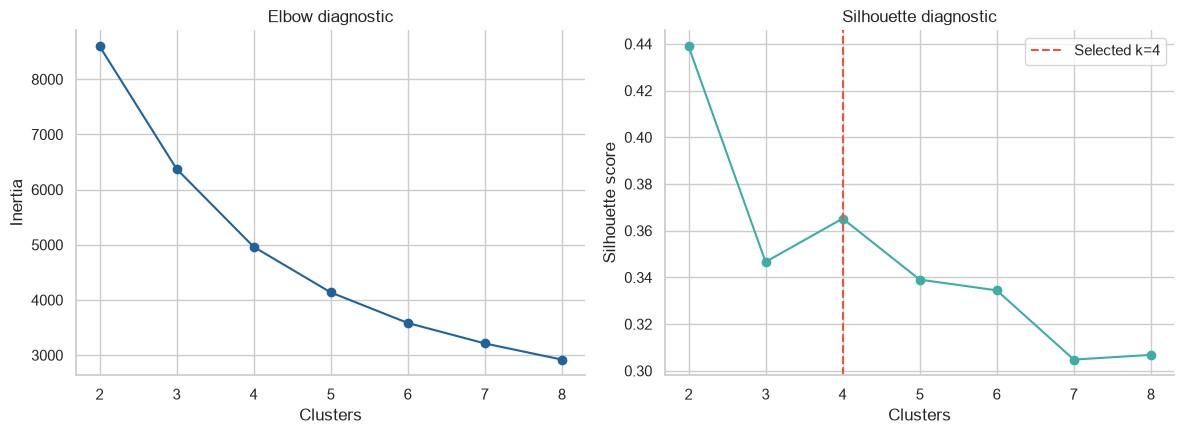

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(cluster_diagnostics["Clusters"], cluster_diagnostics["Inertia"], marker="o", color=COLORS[1])
axes[0].set(title="Elbow diagnostic", xlabel="Clusters", ylabel="Inertia")
axes[1].plot(cluster_diagnostics["Clusters"], cluster_diagnostics["Silhouette"], marker="o", color=COLORS[2])
axes[1].axvline(4, color=COLORS[4], linestyle="--", label="Selected k=4")
axes[1].set(title="Silhouette diagnostic", xlabel="Clusters", ylabel="Silhouette score")
axes[1].legend()
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

In [16]:
best_silhouette_k = int(cluster_diagnostics.loc[cluster_diagnostics["Silhouette"].idxmax(), "Clusters"])
four_cluster_score = cluster_diagnostics.loc[
    cluster_diagnostics["Clusters"] == 4, "Silhouette"
].iloc[0]
display(Markdown(
    f"**Why I used four groups.** The maximum silhouette score occurs at **k={best_silhouette_k}**, which "
    "produces a broad high/low split. I selected **k=4** (silhouette "
    f"**{four_cluster_score:.3f}**) because it preserves reasonable separation while creating four "
    "distinct, actionable customer profiles. This is a business trade-off, not a claim that k=4 is "
    "the mathematically unique answer."
))

**Why I used four groups.** The maximum silhouette score occurs at **k=2**, which produces a broad high/low split. I selected **k=4** (silhouette **0.365**) because it preserves reasonable separation while creating four distinct, actionable customer profiles. This is a business trade-off, not a claim that k=4 is the mathematically unique answer.

In [17]:
kmeans = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Recency=("Recency", "median"),
    Frequency=("Frequency", "median"),
    Monetary=("Monetary", "median"),
)

loyal_cluster = cluster_profile["Monetary"].idxmax()
inactive_cluster = cluster_profile["Recency"].idxmax()
remaining = [c for c in cluster_profile.index if c not in {loyal_cluster, inactive_cluster}]
remaining = cluster_profile.loc[remaining].sort_values("Recency").index.tolist()
segment_map = {
    loyal_cluster: "High Value / Loyal",
    inactive_cluster: "Inactive / Low Value",
    remaining[0]: "Recent / Regular",
    remaining[1]: "At Risk",
}
rfm["Segment"] = rfm["Cluster"].map(segment_map)
segment_profile = rfm.groupby("Segment").agg(
    Customers=("Cluster", "size"),
    MedianRecency=("Recency", "median"),
    MedianFrequency=("Frequency", "median"),
    MedianMonetary=("Monetary", "median"),
).sort_values("MedianMonetary", ascending=False)
segment_profile.round(1)

,Customers,MedianRecency,MedianFrequency,MedianMonetary
Segment,,,,
High Value / Loyal,1117,15.0,13.0,5231.8
At Risk,1474,162.0,5.0,1587.2
Recent / Regular,1231,23.0,3.0,720.9
Inactive / Low Value,2056,400.0,1.0,290.7


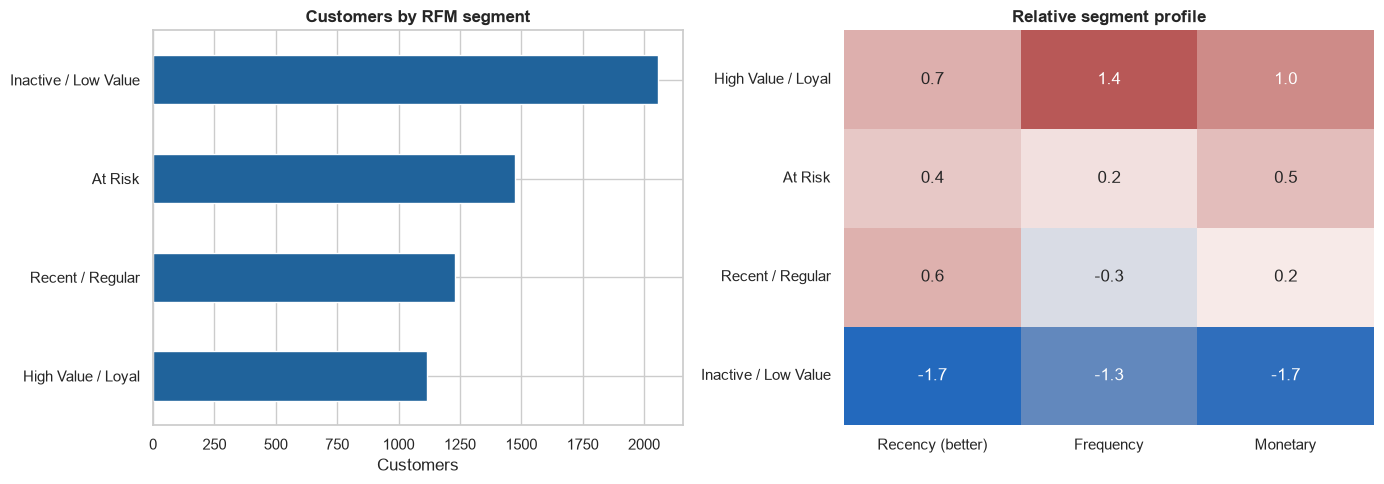

In [18]:
profile_for_heatmap = segment_profile[["MedianRecency", "MedianFrequency", "MedianMonetary"]].copy()
profile_for_heatmap["MedianRecency"] *= -1
profile_z = pd.DataFrame(
    StandardScaler().fit_transform(np.log1p(profile_for_heatmap - profile_for_heatmap.min() + 1)),
    index=profile_for_heatmap.index,
    columns=["Recency (better)", "Frequency", "Monetary"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_profile["Customers"].sort_values().plot(kind="barh", ax=axes[0], color=COLORS[1])
axes[0].set_title("Customers by RFM segment", weight="bold")
axes[0].set_xlabel("Customers")
axes[0].set_ylabel("")
sns.heatmap(profile_z, annot=True, fmt=".1f", cmap="vlag", center=0, ax=axes[1], cbar=False)
axes[1].set_title("Relative segment profile", weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rfm_segments.png", dpi=160, bbox_inches="tight")
plt.show()

In [19]:
recommendations = pd.DataFrame(
    {
        "Segment": ["High Value / Loyal", "Recent / Regular", "At Risk", "Inactive / Low Value"],
        "Recommended action": [
            "Protect loyalty with early access, recognition, and relevant cross-sell offers.",
            "Encourage a second or next purchase with product recommendations and light incentives.",
            "Run a time-limited win-back campaign and prioritize customers with higher historic value.",
            "Use low-cost channels; avoid expensive incentives unless expected value justifies them.",
        ],
    }
)
recommendations

,Segment,Recommended action
0,High Value / Loyal,"Protect loyalty with early access, recognition..."
1,Recent / Regular,Encourage a second or next purchase with produ...
2,At Risk,Run a time-limited win-back campaign and prior...
3,Inactive / Low Value,Use low-cost channels; avoid expensive incenti...


## 5. Predict a purchase in the next 90 days

The model uses the previous 180 days of customer activity. The target is 1 if the customer buys again during the next 90 days.

### Time split

- **Training:** September 2010, December 2010, and March 2011
- **Validation:** June 2011
- **Final test:** September 2011

This setup is closer to real use because all features come before the result we want to predict.

### How the winner is selected

Accuracy is shown, but it does not choose the winner. I use the average of three more useful validation metrics:

- **F1:** balances precision and recall
- **ROC-AUC:** measures how well the model ranks customers
- **Average Precision:** summarizes the precision-recall curve

The model with the highest average score is selected. The final test data is only used after this choice.

### New behavior features

The first version used eight customer features. This version also adds:

- Orders and revenue in the last 30 and 90 days
- Change in orders and revenue during the last 30 days
- Average basket size and largest order value
- Variation in order value and time between orders
- Customer history length and active weeks
- Return value and return rate during the observation window
- Share of purchases made in the United Kingdom

Every feature is created using data before the cutoff date.

The new features are grouped by behavior. Starting with Core RFM, I add one group at a time. A group is kept only if it improves the validation overall score by at least 0.002. The test data is not used for this choice.


In [20]:
def build_customer_snapshot(
    transactions, return_transactions, cutoff, lookback_days=180, horizon_days=90
):
    cutoff = pd.Timestamp(cutoff)
    history_start = cutoff - pd.Timedelta(days=lookback_days)
    outcome_end = cutoff + pd.Timedelta(days=horizon_days)

    all_past = transactions[transactions["InvoiceDate"] < cutoff]
    history = transactions[
        (transactions["InvoiceDate"] >= history_start)
        & (transactions["InvoiceDate"] < cutoff)
    ].copy()
    future = transactions[
        (transactions["InvoiceDate"] >= cutoff)
        & (transactions["InvoiceDate"] < outcome_end)
    ]

    features = history.groupby("Customer ID").agg(
        Recency=("InvoiceDate", lambda x: (cutoff - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        ActiveMonths=("OrderMonth", "nunique"),
        ActiveWeeks=("InvoiceDate", lambda x: x.dt.to_period("W").nunique()),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        UKPurchaseShare=("Country", lambda x: (x == "United Kingdom").mean()),
    )
    features["AvgOrderValue"] = features["Monetary"] / features["Frequency"]

    # Order-level features
    orders = history.groupby(["Customer ID", "Invoice"]).agg(
        OrderDate=("InvoiceDate", "min"),
        OrderValue=("Revenue", "sum"),
        BasketQuantity=("Quantity", "sum"),
    ).reset_index()
    order_stats = orders.groupby("Customer ID").agg(
        MaxOrderValue=("OrderValue", "max"),
        StdOrderValue=("OrderValue", "std"),
        AvgBasketSize=("BasketQuantity", "mean"),
    )
    orders = orders.sort_values(["Customer ID", "OrderDate"])
    orders["DaysBetweenOrders"] = orders.groupby("Customer ID")["OrderDate"].diff().dt.days
    interval_stats = orders.groupby("Customer ID")["DaysBetweenOrders"].agg(
        AvgDaysBetweenOrders="mean",
        StdDaysBetweenOrders="std",
    )
    features = features.join(order_stats).join(interval_stats)

    # Customer history before the cutoff
    first_ever_purchase = all_past.groupby("Customer ID")["InvoiceDate"].min()
    features["CustomerTenure"] = (
        cutoff - first_ever_purchase.reindex(features.index)
    ).dt.days

    # Short-term activity windows
    def window_features(days):
        window = history[history["InvoiceDate"] >= cutoff - pd.Timedelta(days=days)]
        return window.groupby("Customer ID").agg(
            **{
                f"Orders{days}d": ("Invoice", "nunique"),
                f"Revenue{days}d": ("Revenue", "sum"),
            }
        )

    features = features.join(window_features(30)).join(window_features(90))

    previous_30 = history[
        (history["InvoiceDate"] >= cutoff - pd.Timedelta(days=60))
        & (history["InvoiceDate"] < cutoff - pd.Timedelta(days=30))
    ].groupby("Customer ID").agg(
        OrdersPrevious30d=("Invoice", "nunique"),
        RevenuePrevious30d=("Revenue", "sum"),
    )
    features = features.join(previous_30)

    numeric_columns = features.select_dtypes(include=np.number).columns
    features[numeric_columns] = features[numeric_columns].fillna(0)
    features["RevenueTrend30d"] = (
        (features["Revenue30d"] - features["RevenuePrevious30d"])
        / (features["RevenuePrevious30d"].abs() + 1)
    ).clip(-10, 10)
    features["OrdersTrend30d"] = features["Orders30d"] - features["OrdersPrevious30d"]
    features["RecentRevenueShare90d"] = features["Revenue90d"] / (features["Monetary"] + 1)

    # Return behavior inside the same 180-day observation window
    return_history = return_transactions[
        (return_transactions["InvoiceDate"] >= history_start)
        & (return_transactions["InvoiceDate"] < cutoff)
    ].copy()
    return_history["ReturnValue"] = (
        return_history["Quantity"].abs() * return_history["Price"].clip(lower=0)
    )
    return_stats = return_history.groupby("Customer ID").agg(
        ReturnLines180d=("Invoice", "size"),
        ReturnValue180d=("ReturnValue", "sum"),
    )
    features = features.join(return_stats)
    features[["ReturnLines180d", "ReturnValue180d"]] = features[
        ["ReturnLines180d", "ReturnValue180d"]
    ].fillna(0)
    features["ReturnRate180d"] = (
        features["ReturnValue180d"]
        / (features["Monetary"] + features["ReturnValue180d"] + 1)
    )

    features = features.drop(columns=["FirstPurchase", "LastPurchase"])
    features = features.replace([np.inf, -np.inf], 0).fillna(0)

    future_customers = set(future["Customer ID"].unique())
    features["Repeat90d"] = features.index.isin(future_customers).astype(int)
    features["Snapshot"] = cutoff
    return features.reset_index()


train_cutoffs = ["2010-09-01", "2010-12-01", "2011-03-01"]
validation_cutoff = "2011-06-01"
test_cutoff = "2011-09-01"

train_snapshots = pd.concat(
    [build_customer_snapshot(purchases, returns, date) for date in train_cutoffs],
    ignore_index=True,
)
validation_snapshot = build_customer_snapshot(purchases, returns, validation_cutoff)
test_snapshot = build_customer_snapshot(purchases, returns, test_cutoff)

snapshot_summary = pd.DataFrame(
    {
        "Split": ["Training", "Validation", "Test"],
        "Rows": [len(train_snapshots), len(validation_snapshot), len(test_snapshot)],
        "Positive rate": [
            train_snapshots["Repeat90d"].mean(),
            validation_snapshot["Repeat90d"].mean(),
            test_snapshot["Repeat90d"].mean(),
        ],
    }
)
snapshot_summary_display = snapshot_summary.copy()
snapshot_summary_display["Rows"] = snapshot_summary_display["Rows"].map("{:,}".format)
snapshot_summary_display["Positive rate"] = snapshot_summary_display["Positive rate"].map("{:.1%}".format)
snapshot_summary_display

,Split,Rows,Positive rate
0,Training,"9,659",46.5%
1,Validation,"2,659",50.1%
2,Test,"2,772",60.7%


,Precision,Recall,F1,ROC-AUC,Average precision,Overall score
Feature set,,,,,,
Core + Customer history,0.725,0.601,0.657,0.744,0.766,0.722
Core + Engagement,0.800,0.471,0.593,0.741,0.778,0.704
Core + Revenue & basket,0.790,0.471,0.590,0.744,0.774,0.703
Core + Returns,0.797,0.454,0.578,0.741,0.771,0.697
Core RFM,0.796,0.459,0.582,0.736,0.766,0.695
Core + Market,0.789,0.463,0.583,0.735,0.766,0.694


,Step,Added group,Features,Overall score,Improvement
0,0,Core RFM,3,0.695,NaN
1,1,Customer history,6,0.722,0.028
2,2,Engagement,12,0.731,0.008
3,3,Revenue & basket,23,0.733,0.002


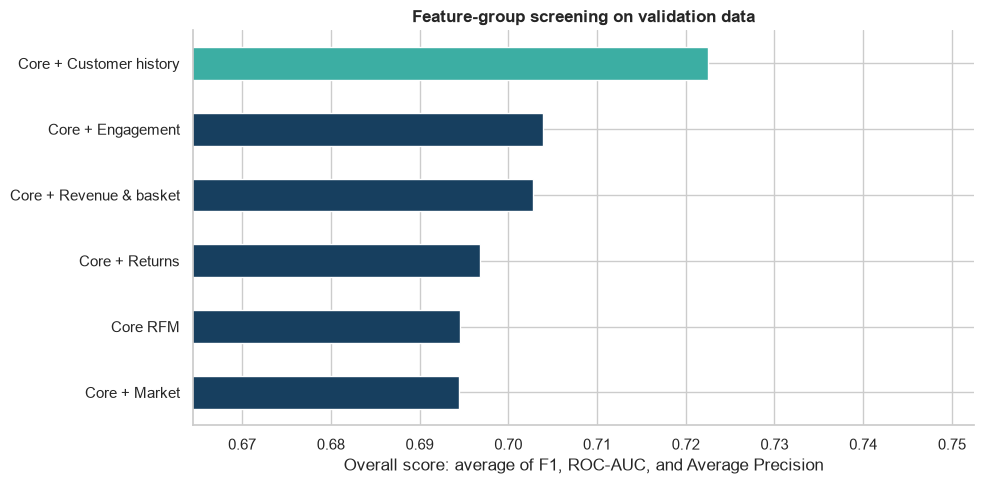

**Selected feature groups:** Core RFM, Customer history, Engagement, Revenue & basket. The final model uses **23 features**.

,Accuracy,Precision,Recall,F1,ROC-AUC,Average precision,Overall score
Model,,,,,,,
Logistic regression,0.695,0.752,0.585,0.658,0.756,0.786,0.733
XGBoost,0.692,0.778,0.537,0.636,0.762,0.790,0.729
Gradient boosting,0.677,0.773,0.502,0.609,0.745,0.778,0.711
Majority baseline,0.499,0.000,0.000,0.000,0.500,0.501,0.334


In [21]:
feature_columns = [
    "Recency", "Frequency", "Monetary", "UniqueProducts", "TotalQuantity",
    "ActiveMonths", "ActiveWeeks", "AvgOrderValue", "UKPurchaseShare", "CustomerTenure",
    "MaxOrderValue", "StdOrderValue", "AvgBasketSize",
    "AvgDaysBetweenOrders", "StdDaysBetweenOrders",
    "Orders30d", "Revenue30d", "Orders90d", "Revenue90d",
    "OrdersPrevious30d", "RevenuePrevious30d",
    "RevenueTrend30d", "OrdersTrend30d", "RecentRevenueShare90d",
    "ReturnLines180d", "ReturnValue180d", "ReturnRate180d",
]
target = "Repeat90d"
all_feature_columns = feature_columns.copy()

core_features = ["Recency", "Frequency", "Monetary"]
feature_groups = {
    "Engagement": [
        "ActiveMonths", "ActiveWeeks", "Orders30d", "Orders90d",
        "OrdersPrevious30d", "OrdersTrend30d",
    ],
    "Customer history": [
        "CustomerTenure", "AvgDaysBetweenOrders", "StdDaysBetweenOrders",
    ],
    "Revenue & basket": [
        "UniqueProducts", "TotalQuantity", "AvgOrderValue", "MaxOrderValue",
        "StdOrderValue", "AvgBasketSize", "Revenue30d", "Revenue90d",
        "RevenuePrevious30d", "RevenueTrend30d", "RecentRevenueShare90d",
    ],
    "Returns": ["ReturnLines180d", "ReturnValue180d", "ReturnRate180d"],
    "Market": ["UKPurchaseShare"],
}

def score_feature_set(columns):
    model = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    model.fit(train_snapshots[columns], train_snapshots[target])
    probability = model.predict_proba(validation_snapshot[columns])[:, 1]
    prediction = (probability >= 0.5).astype(int)
    result = {
        "Precision": precision_score(validation_snapshot[target], prediction, zero_division=0),
        "Recall": recall_score(validation_snapshot[target], prediction, zero_division=0),
        "F1": f1_score(validation_snapshot[target], prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(validation_snapshot[target], probability),
        "Average precision": average_precision_score(validation_snapshot[target], probability),
    }
    result["Overall score"] = np.mean([
        result["F1"], result["ROC-AUC"], result["Average precision"]
    ])
    return result

# First, compare each behavior group when it is added to Core RFM.
screening_rows = [{"Feature set": "Core RFM", **score_feature_set(core_features)}]
for group_name, group_columns in feature_groups.items():
    screening_rows.append({
        "Feature set": f"Core + {group_name}",
        **score_feature_set(core_features + group_columns),
    })
group_screening = (
    pd.DataFrame(screening_rows)
    .set_index("Feature set")
    .sort_values("Overall score", ascending=False)
)
display(group_screening.round(3))

# Then add groups one at a time and stop when improvement is smaller than 0.002.
selected_groups = ["Core RFM"]
selected_features = core_features.copy()
current_result = score_feature_set(selected_features)
selection_history = [{
    "Step": 0,
    "Added group": "Core RFM",
    "Features": len(selected_features),
    "Overall score": current_result["Overall score"],
    "Improvement": np.nan,
}]
remaining_groups = feature_groups.copy()

while remaining_groups:
    candidates = []
    for group_name, group_columns in remaining_groups.items():
        candidate_features = selected_features + group_columns
        result = score_feature_set(candidate_features)
        candidates.append((result["Overall score"], group_name, group_columns, result))

    best_score, best_group, best_columns, best_result = max(candidates, key=lambda x: x[0])
    improvement = best_score - current_result["Overall score"]
    if improvement < 0.002:
        break

    selected_groups.append(best_group)
    selected_features.extend(best_columns)
    current_result = best_result
    remaining_groups.pop(best_group)
    selection_history.append({
        "Step": len(selection_history),
        "Added group": best_group,
        "Features": len(selected_features),
        "Overall score": best_score,
        "Improvement": improvement,
    })

selection_history = pd.DataFrame(selection_history)
display(selection_history.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
plot_values = group_screening["Overall score"].sort_values()
colors = [COLORS[2] if label == plot_values.idxmax() else COLORS[0] for label in plot_values.index]
plot_values.plot(kind="barh", color=colors, ax=ax)
ax.set_title("Feature-group screening on validation data", weight="bold")
ax.set_xlabel("Overall score: average of F1, ROC-AUC, and Average Precision")
ax.set_ylabel("")
ax.set_xlim(max(0, plot_values.min() - 0.03), min(1, plot_values.max() + 0.03))
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_group_screening.png", dpi=160, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Selected feature groups:** {', '.join(selected_groups)}. "
    f"The final model uses **{len(selected_features)} features**."
))

feature_columns = selected_features
X_train, y_train = train_snapshots[feature_columns], train_snapshots[target]
X_val, y_val = validation_snapshot[feature_columns], validation_snapshot[target]
X_test, y_test = test_snapshot[feature_columns], test_snapshot[target]

models = {
    "Majority baseline": DummyClassifier(strategy="prior"),
    "Logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "XGBoost": XGBClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=2.0,
        eval_metric="aucpr",
        early_stopping_rounds=50,
        tree_method="hist",
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    "Gradient boosting": HistGradientBoostingClassifier(
        max_iter=180, learning_rate=0.05, max_leaf_nodes=15,
        l2_regularization=0.1, random_state=RANDOM_STATE,
    ),
}

fitted_validation_models = {}
validation_rows = []
for name, estimator in models.items():
    fitted = clone(estimator)
    if name == "XGBoost":
        fitted.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else:
        fitted.fit(X_train, y_train)
    probability = fitted.predict_proba(X_val)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    fitted_validation_models[name] = fitted
    validation_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_val, prediction),
            "Precision": precision_score(y_val, prediction, zero_division=0),
            "Recall": recall_score(y_val, prediction, zero_division=0),
            "F1": f1_score(y_val, prediction, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, probability),
            "Average precision": average_precision_score(y_val, probability),
        }
    )

validation_results = pd.DataFrame(validation_rows).set_index("Model")
selection_metrics = ["F1", "ROC-AUC", "Average precision"]
validation_results["Overall score"] = validation_results[selection_metrics].mean(axis=1)
validation_results = validation_results.sort_values("Overall score", ascending=False)
validation_results.round(3)

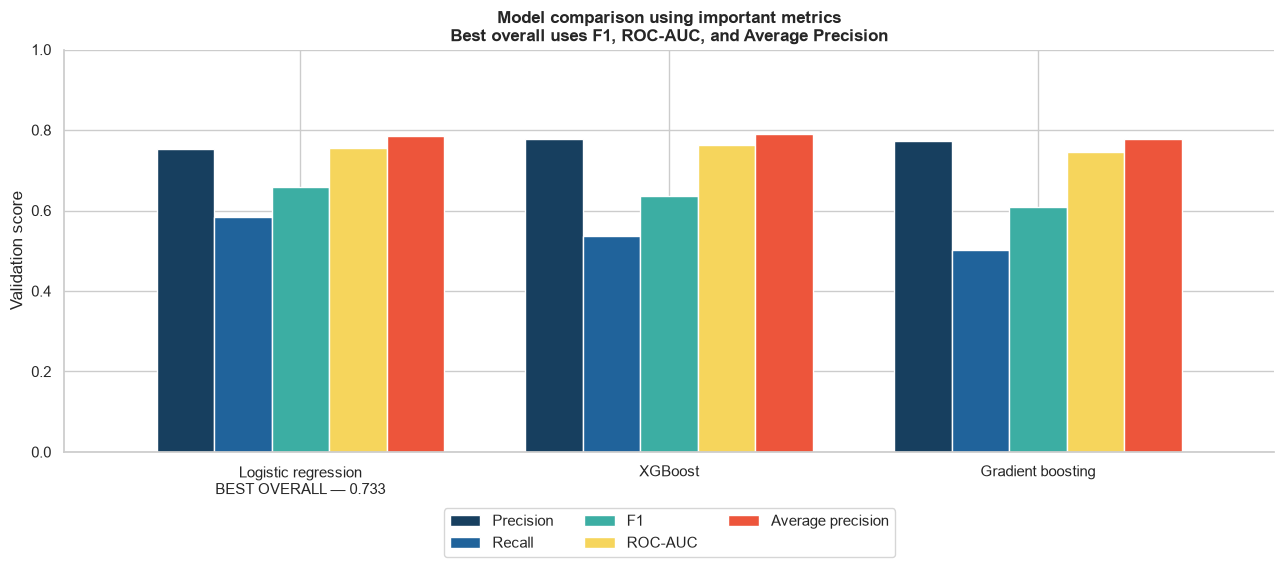

**Model choice.** The models are close. **Logistic regression** has the best overall validation score (**0.733**). Its lead over the next model is only **0.004**. No model is best on every metric, so this score uses several measures instead of accuracy alone.

,Accuracy,Precision,Recall,F1,ROC-AUC,Average precision
Majority baseline,0.393,0.000,0.00,0.00,0.500,0.607
Logistic regression,0.667,0.704,0.78,0.74,0.737,0.824


In [22]:
candidate_names = [name for name in models if name != "Majority baseline"]
selected_name = validation_results.loc[candidate_names, "Overall score"].idxmax()

score_gap = (
    validation_results.loc[candidate_names, "Overall score"].nlargest(2).iloc[0]
    - validation_results.loc[candidate_names, "Overall score"].nlargest(2).iloc[1]
)

chart_metrics = ["Precision", "Recall", "F1", "ROC-AUC", "Average precision"]
chart_data = validation_results.loc[candidate_names, chart_metrics]

fig, ax = plt.subplots(figsize=(13, 6))
chart_data.plot(kind="bar", ax=ax, color=COLORS[:5], width=0.78)
labels = [
    f"{name}\nBEST OVERALL — {validation_results.loc[name, 'Overall score']:.3f}"
    if name == selected_name else name
    for name in chart_data.index
]
ax.set_xticklabels(labels, rotation=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Validation score")
ax.set_xlabel("")
ax.set_title("Model comparison using important metrics\nBest overall uses F1, ROC-AUC, and Average Precision", weight="bold")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.28))
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Model choice.** The models are close. **{selected_name}** has the best overall validation score "
    f"(**{validation_results.loc[selected_name, 'Overall score']:.3f}**). "
    f"Its lead over the next model is only **{score_gap:.3f}**. "
    "No model is best on every metric, so this score uses several measures instead of accuracy alone."
))
selected_validation_model = fitted_validation_models[selected_name]
validation_probability = selected_validation_model.predict_proba(X_val)[:, 1]

precision_values, recall_values, thresholds = precision_recall_curve(y_val, validation_probability)
f1_values = 2 * precision_values * recall_values / (precision_values + recall_values + 1e-12)
selected_threshold = thresholds[np.argmax(f1_values[:-1])]

combined = pd.concat([train_snapshots, validation_snapshot], ignore_index=True)
final_estimator = clone(models[selected_name])
if selected_name == "XGBoost":
    best_trees = fitted_validation_models["XGBoost"].best_iteration + 1
    final_estimator.set_params(n_estimators=best_trees, early_stopping_rounds=None)
final_model = final_estimator.fit(combined[feature_columns], combined[target])
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

baseline_model = clone(models["Majority baseline"]).fit(combined[feature_columns], combined[target])
baseline_probability = baseline_model.predict_proba(X_test)[:, 1]
baseline_prediction = baseline_model.predict(X_test)

def classification_metrics(y_true, prediction, probability):
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "Average precision": average_precision_score(y_true, probability),
    }

test_results = pd.DataFrame(
    {
        "Majority baseline": classification_metrics(y_test, baseline_prediction, baseline_probability),
        selected_name: classification_metrics(y_test, test_prediction, test_probability),
    }
).T
test_results.round(3)

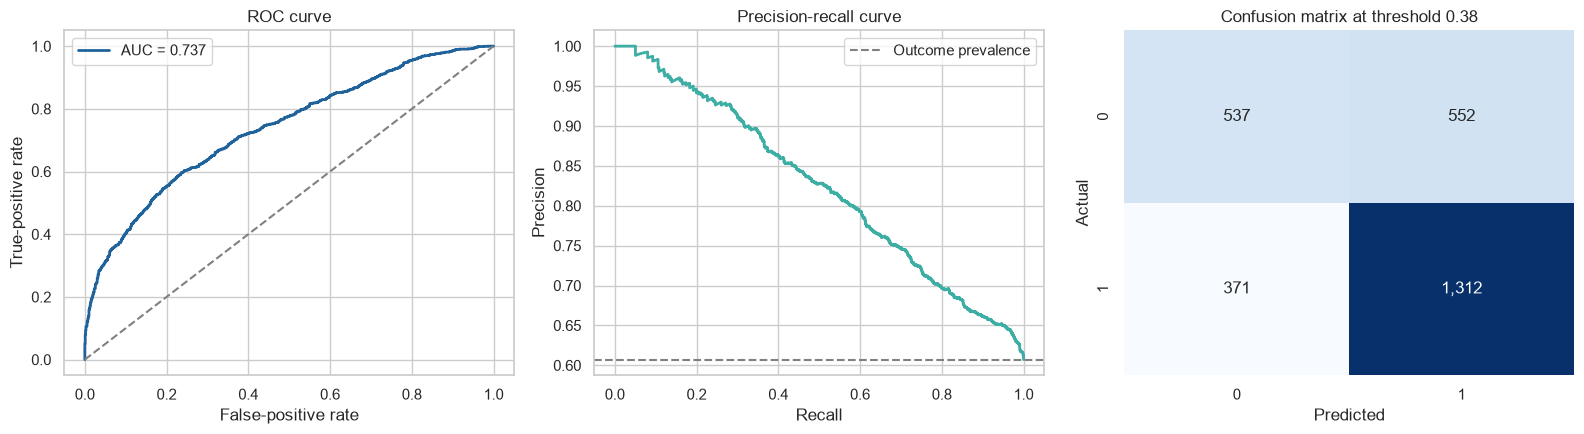

In [23]:
fpr, tpr, _ = roc_curve(y_test, test_probability)
test_precision, test_recall, _ = precision_recall_curve(y_test, test_probability)
cm = confusion_matrix(y_test, test_prediction)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(fpr, tpr, color=COLORS[1], linewidth=2,
             label=f"AUC = {test_results.loc[selected_name, 'ROC-AUC']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[0].legend()

axes[1].plot(test_recall, test_precision, color=COLORS[2], linewidth=2)
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Outcome prevalence")
axes[1].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()

sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set(title=f"Confusion matrix at threshold {selected_threshold:.2f}",
            xlabel="Predicted", ylabel="Actual")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()

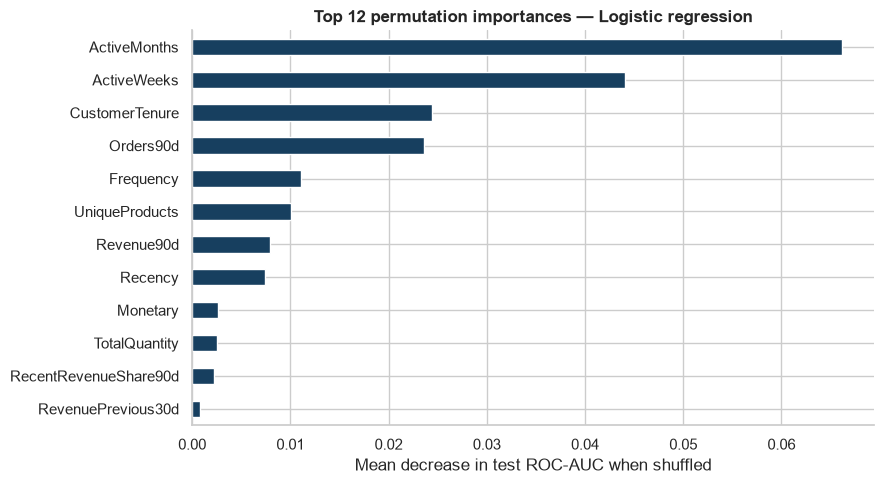

In [24]:
importance = permutation_importance(
    final_model, X_test, y_test, scoring="roc_auc", n_repeats=8,
    n_jobs=1, random_state=RANDOM_STATE,
)
feature_importance = pd.Series(
    importance.importances_mean, index=feature_columns, name="Decrease in ROC-AUC"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feature_importance.tail(12).plot(kind="barh", color=COLORS[0], ax=ax)
ax.set_title(f"Top 12 permutation importances — {selected_name}", weight="bold")
ax.set_xlabel("Mean decrease in test ROC-AUC when shuffled")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

In [25]:
strongest_feature = feature_importance.idxmax()
display(Markdown(
    f"**Final test result.** Feature selection kept **{', '.join(selected_groups)}** "
    f"(**{len(feature_columns)} features**). **{selected_name}** was selected from the validation results. "
    f"On the September 2011 test group, "
    f"it reached **{test_results.loc[selected_name, 'ROC-AUC']:.3f} ROC-AUC**, "
    f"**{test_results.loc[selected_name, 'F1']:.3f} F1**, and "
    f"**{test_results.loc[selected_name, 'Recall']:.1%} recall**. The probability cutoff was "
    f"**{selected_threshold:.2f}**, based on the validation data. The most useful feature was "
    f"**{strongest_feature}**. The model can help rank customers for a campaign, but it cannot "
    "prove that the campaign will cause a purchase."
))

**Final test result.** Feature selection kept **Core RFM, Customer history, Engagement, Revenue & basket** (**23 features**). **Logistic regression** was selected from the validation results. On the September 2011 test group, it reached **0.737 ROC-AUC**, **0.740 F1**, and **78.0% recall**. The probability cutoff was **0.38**, based on the validation data. The most useful feature was **ActiveMonths**. The model can help rank customers for a campaign, but it cannot prove that the campaign will cause a purchase.

## 6. What the retailer can do

1. Focus first on valuable customers who may be leaving.
2. Use low-cost messages for low-value customers and stronger offers only when the expected value is high enough.
3. Test campaigns with a control group. A prediction does not prove that a discount caused a purchase.
4. Check the model again over time, especially because sales change during the holiday season.

## Limits of this project

- Many transactions do not have a customer ID.
- Returns are kept separate but are not matched to the original purchase.
- The data does not include marketing cost, profit, or customer demographics.
- The model predicts behavior; it does not prove cause and effect.
- This is an older public dataset, so a current store may behave differently.

## Final takeaway

This project turns raw sales data into customer groups and a repeat-purchase model. The results can help a retailer decide which customers may need attention, but campaign decisions should also consider customer value and the cost of the offer.